# UCI Adult - Analyzing Income Factors
**EPITA – MSc Artificial Intelligence Systems (AIS)**  
**Spark & Python for Big Data AIS S2 F25**

**Students:**
- TRUONG Kim Tan
- LE Linh Long
- Farouk RAHAL

---

## Step 0: Imports and Data Loading

### 0.1. Imports

In [28]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.feature import PCA
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

### 0.2. Spark Session Initialization

In [29]:
spark = SparkSession.builder \
    .appName("AdultCensusIncome_Spark") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .getOrCreate()

print(f"Spark version: {spark.version}")
spark.sparkContext.getConf().getAll()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/02 16:30:15 WARN Utils: Your hostname, MacBook-Pro-cua-Nguyen.local, resolves to a loopback address: 127.0.0.1; using 10.41.178.0 instead (on interface en0)
26/03/02 16:30:15 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/02 16:30:16 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.1.1


[('spark.sql.warehouse.dir',
  'file:/Users/alex0702/study-at-epita/spark/UCI-Adult-Analyzing-Income-Factors/spark-warehouse'),
 ('spark.rdd.compress', 'True'),
 ('spark.hadoop.fs.s3a.vectored.read.min.seek.size', '128K'),
 ('spark.sql.artifact.isolation.enabled', 'false'),
 ('spark.executor.extraJavaOptions',
  '-Djava.net.preferIPv6Addresses=false -XX:+IgnoreUnrecognizedVMOptions --add-modules=jdk.incubator.vector --add-opens=java.base/java.lang=ALL-UNNAMED --add-opens=java.base/java.lang.invoke=ALL-UNNAMED --add-opens=java.base/java.lang.reflect=ALL-UNNAMED --add-opens=java.base/java.io=ALL-UNNAMED --add-opens=java.base/java.net=ALL-UNNAMED --add-opens=java.base/java.nio=ALL-UNNAMED --add-opens=java.base/java.util=ALL-UNNAMED --add-opens=java.base/java.util.concurrent=ALL-UNNAMED --add-opens=java.base/java.util.concurrent.atomic=ALL-UNNAMED --add-opens=java.base/jdk.internal.ref=ALL-UNNAMED --add-opens=java.base/sun.nio.ch=ALL-UNNAMED --add-opens=java.base/sun.nio.cs=ALL-UNNAMED --a

### 0.3. Data Loading with Spark

In [30]:
csv_file = glob.glob(f"adult.csv", recursive=True)[0]

# Define schema
schema = StructType([
    StructField("age", IntegerType(), True),
    StructField("workclass", StringType(), True),
    StructField("fnlwgt", IntegerType(), True),
    StructField("education", StringType(), True),
    StructField("education_num", IntegerType(), True),
    StructField("marital_status", StringType(), True),
    StructField("occupation", StringType(), True),
    StructField("relationship", StringType(), True),
    StructField("race", StringType(), True),
    StructField("sex", StringType(), True),
    StructField("capital_gain", IntegerType(), True),
    StructField("capital_loss", IntegerType(), True),
    StructField("hours_per_week", IntegerType(), True),
    StructField("native_country", StringType(), True),
    StructField("income", StringType(), True)
])

df = spark.read.csv(csv_file, schema=schema, header=True,
                    nullValue="?",
                    ignoreLeadingWhiteSpace=True,
                    ignoreTrailingWhiteSpace=True)

df.cache()

print("Schema:")
df.printSchema()
print(f"Total records: {df.count():,}")
df.show(5, truncate=False)

Schema:
root
 |-- age: integer (nullable = true)
 |-- workclass: string (nullable = true)
 |-- fnlwgt: integer (nullable = true)
 |-- education: string (nullable = true)
 |-- education_num: integer (nullable = true)
 |-- marital_status: string (nullable = true)
 |-- occupation: string (nullable = true)
 |-- relationship: string (nullable = true)
 |-- race: string (nullable = true)
 |-- sex: string (nullable = true)
 |-- capital_gain: integer (nullable = true)
 |-- capital_loss: integer (nullable = true)
 |-- hours_per_week: integer (nullable = true)
 |-- native_country: string (nullable = true)
 |-- income: string (nullable = true)



26/03/02 16:30:18 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: age, workclass, fnlwgt, education, education.num, marital.status, occupation, relationship, race, sex, capital.gain, capital.loss, hours.per.week, native.country, income
 Schema: age, workclass, fnlwgt, education, education_num, marital_status, occupation, relationship, race, sex, capital_gain, capital_loss, hours_per_week, native_country, income
Expected: education_num but found: education.num
CSV file: file:///Users/nguyenrichard/Desktop/Data%20Science/Spark%20&%20Python%20for%20Big%20Data/UCI-Adult-Analyzing-Income-Factors/adult.csv


Total records: 32,561
+---+---------+------+------------+-------------+--------------+-----------------+-------------+-----+------+------------+------------+--------------+--------------+------+
|age|workclass|fnlwgt|education   |education_num|marital_status|occupation       |relationship |race |sex   |capital_gain|capital_loss|hours_per_week|native_country|income|
+---+---------+------+------------+-------------+--------------+-----------------+-------------+-----+------+------------+------------+--------------+--------------+------+
|90 |NULL     |77053 |HS-grad     |9            |Widowed       |NULL             |Not-in-family|White|Female|0           |4356        |40            |United-States |<=50K |
|82 |Private  |132870|HS-grad     |9            |Widowed       |Exec-managerial  |Not-in-family|White|Female|0           |4356        |18            |United-States |<=50K |
|66 |NULL     |186061|Some-college|10           |Widowed       |NULL             |Unmarried    |Black|Female|0   

26/03/02 16:12:56 WARN CacheManager: Asked to cache already cached data.


### 0.4. Data Exploration

#### a. Dataset Overview

In [31]:
df.printSchema()

root
 |-- age: integer (nullable = true)
 |-- workclass: string (nullable = true)
 |-- fnlwgt: integer (nullable = true)
 |-- education: string (nullable = true)
 |-- education_num: integer (nullable = true)
 |-- marital_status: string (nullable = true)
 |-- occupation: string (nullable = true)
 |-- relationship: string (nullable = true)
 |-- race: string (nullable = true)
 |-- sex: string (nullable = true)
 |-- capital_gain: integer (nullable = true)
 |-- capital_loss: integer (nullable = true)
 |-- hours_per_week: integer (nullable = true)
 |-- native_country: string (nullable = true)
 |-- income: string (nullable = true)



#### b. Missing Values

In [32]:
df.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c)
    for c in df.columns
]).show()

+---+---------+------+---------+-------------+--------------+----------+------------+----+---+------------+------------+--------------+--------------+------+
|age|workclass|fnlwgt|education|education_num|marital_status|occupation|relationship|race|sex|capital_gain|capital_loss|hours_per_week|native_country|income|
+---+---------+------+---------+-------------+--------------+----------+------------+----+---+------------+------------+--------------+--------------+------+
|  0|     1836|     0|        0|            0|             0|      1843|           0|   0|  0|           0|           0|             0|           583|     0|
+---+---------+------+---------+-------------+--------------+----------+------------+----+---+------------+------------+--------------+--------------+------+



#### c. Data Distribution

In [33]:
df.groupBy("income").count() \
  .withColumn("percentage", F.col("count") / df.count() * 100) \
  .show()

+------+-----+------------------+
|income|count|        percentage|
+------+-----+------------------+
| <=50K|24720| 75.91904425539757|
|  >50K| 7841|24.080955744602438|
+------+-----+------------------+



#### d. Correlation Matrix

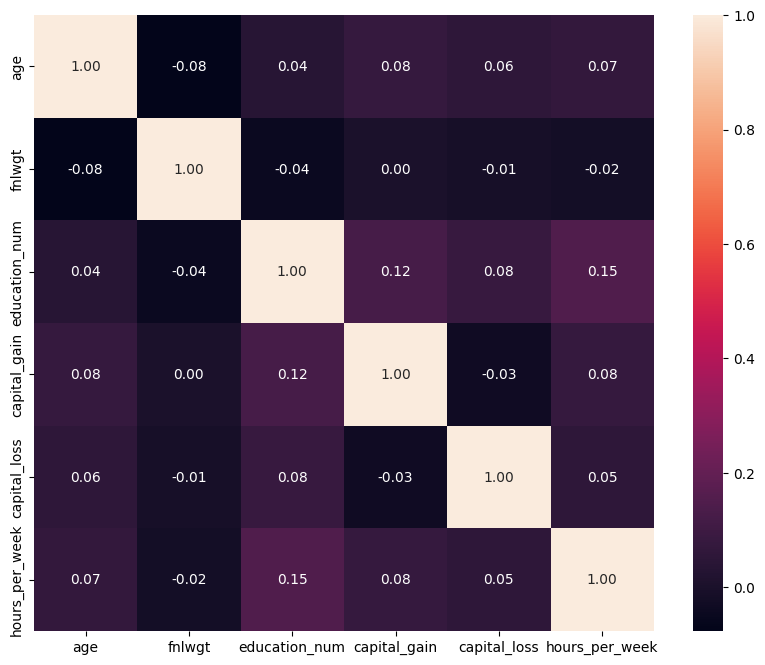

In [34]:
numeric_cols = [c for c, t in df.dtypes if t in ["int", "double"]]
pdf = df.select(numeric_cols).toPandas()

plt.figure(figsize=(10,8))
sns.heatmap(pdf.corr(), annot=True, fmt=".2f")
plt.show()

## Step 1: Data Cleaning and Preparation

### 1.1. Handling Missing Values

#### a. Creating $Unknown$ category for missing values

In [35]:
workclass_mode_df = df.filter(F.isnull('workclass') == False) \
    .groupBy('workclass') \
    .count() \
    .orderBy(F.desc('count'))

workclass_mode_df.show()
workclass_mode = workclass_mode_df.first()['workclass']
print(f"Mode for workclass: '{workclass_mode}'")

+----------------+-----+
|       workclass|count|
+----------------+-----+
|         Private|22696|
|Self-emp-not-inc| 2541|
|       Local-gov| 2093|
|       State-gov| 1298|
|    Self-emp-inc| 1116|
|     Federal-gov|  960|
|     Without-pay|   14|
|    Never-worked|    7|
+----------------+-----+

Mode for workclass: 'Private'


#### b. Verification

In [36]:
occupation_mode_df = df.filter(F.isnull('occupation') == False) \
    .groupBy('occupation') \
    .count() \
    .orderBy(F.desc('count'))

occupation_mode_df.show()
occupation_mode = occupation_mode_df.first()['occupation']
print(f"Mode for occupation: '{occupation_mode}'")

Workclass nulls remaining: 0
Occupation nulls remaining: 0
Native country nulls remaining: 0


#### c. Impute Missing Values with $mode$

In [37]:
df_imputed = df.withColumn(
    'workclass',
    F.when(F.isnull('workclass'), workclass_mode).otherwise(F.col('workclass'))
).withColumn(
    'occupation',
    F.when(F.isnull('occupation'), occupation_mode).otherwise(F.col('occupation'))
)

#### d. Verify Imputation

In [38]:
print(f"No. workclass nulls: {df_imputed.filter(F.isnull('workclass')).count():,}")
print(f"No. occupation nulls: {df_imputed.filter(F.isnull('occupation')).count():,}")

df = df_imputed

No. workclass nulls: 0
No. occupation nulls: 0


### 1.2. Redundancy Check

#### a. Unique combinations of `education` and `education_num`

In [39]:
education_mapping = df.groupBy("education", "education_num").count().orderBy("education_num")
education_mapping.show(truncate=False)

print(f"Total unique education levels: {df.select('education').distinct().count()}")
print(f"Total unique education_num values: {df.select('education_num').distinct().count()}")

+------------+-------------+-----+
|education   |education_num|count|
+------------+-------------+-----+
|Preschool   |1            |51   |
|1st-4th     |2            |168  |
|5th-6th     |3            |333  |
|7th-8th     |4            |646  |
|9th         |5            |514  |
|10th        |6            |933  |
|11th        |7            |1175 |
|12th        |8            |433  |
|HS-grad     |9            |10501|
|Some-college|10           |7291 |
|Assoc-voc   |11           |1382 |
|Assoc-acdm  |12           |1067 |
|Bachelors   |13           |5355 |
|Masters     |14           |1723 |
|Prof-school |15           |576  |
|Doctorate   |16           |413  |
+------------+-------------+-----+

Total unique education levels: 16
Total unique education_num values: 16


#### b. One-to-one Mapping Check

In [40]:
mapping_count = education_mapping.count()
unique_education = df.select("education").distinct().count()
unique_education_num = df.select("education_num").distinct().count()

print(f"Number of (education, education_num) pairs: {mapping_count}")

if mapping_count == unique_education == unique_education_num:
    print("Every education label maps to exactly one education_num")

    # Show the mapping for reference
    print("Education Mapping Reference: ")
    mapping_df = education_mapping.select("education", "education_num").orderBy("education_num")
    mapping_df.show(truncate=False)

Number of (education, education_num) pairs: 16
Every education label maps to exactly one education_num
Education Mapping Reference: 
+------------+-------------+
|education   |education_num|
+------------+-------------+
|Preschool   |1            |
|1st-4th     |2            |
|5th-6th     |3            |
|7th-8th     |4            |
|9th         |5            |
|10th        |6            |
|11th        |7            |
|12th        |8            |
|HS-grad     |9            |
|Some-college|10           |
|Assoc-voc   |11           |
|Assoc-acdm  |12           |
|Bachelors   |13           |
|Masters     |14           |
|Prof-school |15           |
|Doctorate   |16           |
+------------+-------------+



From the One-to-one mapping check, we can see that:
- Every education label maps to exactly 1 education_num
- And every education_num maps to exactly 1 education label
So the relationship is 1-to-1. Therefore, we'll drop the `education` column and keep the `education_num` because we want to work with numerical features for machine learning.

#### c. Redundancy Drop

In [41]:
df = df.drop("education")

### 1.3. Categorical Columns Cleaning

#### a. Categorical Columns

In [42]:
categorical_cols = [field.name for field in df.schema.fields if str(field.dataType) == "StringType()"]
print(f"Categorical columns: {categorical_cols}")


Categorical columns: ['workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'income']


#### b. Categorical Columns Cleaning

In [43]:
whitespace_cleaned = []
for col_name in categorical_cols:
    print(f"Checking column: '{col_name}'")

    # We will check for leading/trailing whitespace using rlike (regex)
    has_whitespace = df.filter(F.col(col_name).rlike("^\\s+|\\s+$")).count()

    print(f"  Records with surrounding whitespace: {has_whitespace}")

    if has_whitespace > 0:
        print(f"  Cleaning whitespace in '{col_name}'")
        df = df.withColumn(col_name, F.trim(F.col(col_name)))
        whitespace_cleaned.append(col_name)
    else:
        print(f"  No surrounding whitespace found in '{col_name}'")

print("-"*40)
print(f"Whitespace Cleaning Summary")
print("-"*40)
if whitespace_cleaned:
    print(f"Cleaned columns: {whitespace_cleaned}")
else:
    print("No whitespace issues found in any columns")

Checking column: 'workclass'
  Records with surrounding whitespace: 0
  No surrounding whitespace found in 'workclass'
Checking column: 'marital_status'
  Records with surrounding whitespace: 0
  No surrounding whitespace found in 'marital_status'
Checking column: 'occupation'
  Records with surrounding whitespace: 0
  No surrounding whitespace found in 'occupation'
Checking column: 'relationship'
  Records with surrounding whitespace: 0
  No surrounding whitespace found in 'relationship'
Checking column: 'race'
  Records with surrounding whitespace: 0
  No surrounding whitespace found in 'race'
Checking column: 'sex'
  Records with surrounding whitespace: 0
  No surrounding whitespace found in 'sex'
Checking column: 'native_country'
  Records with surrounding whitespace: 0
  No surrounding whitespace found in 'native_country'
Checking column: 'income'
  Records with surrounding whitespace: 0
  No surrounding whitespace found in 'income'
----------------------------------------
Whitesp

## Step 2 : Feature Transformation and Engineering

### a. Target Transformation

In [44]:
df = df.withColumn(
    "label",
    F.when(F.col("income") == ">50K", 1).otherwise(0)
).drop("income")

df.groupBy("label").count().show()

+-----+-----+
|label|count|
+-----+-----+
|    1| 7841|
|    0|24720|
+-----+-----+



### b. Analyzing Capital Gains/Losse

In [ ]:
df = df.withColumn("net_capital", F.col("capital_gain") - F.col("capital_loss"))
df.groupBy("label") \
  .agg(F.avg("net_capital").alias("avg_net_capital"),
       F.count("*").alias("count")) \
  .orderBy("label") \
  .show()
df = df.drop("capital_gain", "capital_loss")

+-----+------------------+-----+
|label|   avg_net_capital|count|
+-----+------------------+-----+
|    0| 95.60954692556635|24720|
|    1|3811.1409259023085| 7841|
+-----+------------------+-----+



### c. Label Encoding

In [46]:
cols = ["workclass", "marital_status", "occupation", "relationship"]

# Step 3: Unsupervised Learning

In [47]:
df_pandas = df.toPandas()
print(df_pandas.head())
df_pandas.to_csv("sample.csv", index=False)

   age workclass  fnlwgt  education_num marital_status         occupation  \
0   90   Private   77053              9        Widowed     Prof-specialty   
1   82   Private  132870              9        Widowed    Exec-managerial   
2   66   Private  186061             10        Widowed     Prof-specialty   
3   54   Private  140359              4       Divorced  Machine-op-inspct   
4   41   Private  264663             10      Separated     Prof-specialty   

    relationship   race     sex  capital_gain  capital_loss  hours_per_week  \
0  Not-in-family  White  Female             0          4356              40   
1  Not-in-family  White  Female             0          4356              18   
2      Unmarried  Black  Female             0          4356              40   
3      Unmarried  White  Female             0          3900              40   
4      Own-child  White  Female             0          3900              40   

  native_country  label  net_capital  
0  United-States      0

In [48]:
df_pandas["native_country"].value_counts()

native_country
United-States                 29170
Mexico                          643
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                     114
El-Salvador                     106
India                           100
Cuba                             95
England                          90
Jamaica                          81
South                            80
China                            75
Italy                            73
Dominican-Republic               70
Vietnam                          67
Guatemala                        64
Japan                            62
Poland                           60
Columbia                         59
Taiwan                           51
Haiti                            44
Iran                             43
Portugal                         37
Nicaragua                        34
Peru                             31
Greece                           29
France       

In [48]:
df_pandas["native_country"].value_counts()

native_country
United-States                 29170
Mexico                          643
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                     114
El-Salvador                     106
India                           100
Cuba                             95
England                          90
Jamaica                          81
South                            80
China                            75
Italy                            73
Dominican-Republic               70
Vietnam                          67
Guatemala                        64
Japan                            62
Poland                           60
Columbia                         59
Taiwan                           51
Haiti                            44
Iran                             43
Portugal                         37
Nicaragua                        34
Peru                             31
Greece                           29
France       